# Exam Project - Introduction to Social Data Science
August 28, 2024

## Project: Forecasting Vote Counts for Danish Borgerforslag

## Group 7:
- Oliver Nyrop Weeks (vsn684)
- Sofus Galavits Møller (qvc730)
- Victor V. Kristensen (gcp458)
- Jonas T. Schmidt (mcp656)

## Load modules

In [1]:
# Module Imports
import pandas as pd            # For data manipulation and analysis
from bs4 import BeautifulSoup  # For parsing HTML content
import time                    # For managing time delays during scraping
import tqdm                    # For displaying progress bars during scraping
import pprint                  # For neatly displaying JSON cod
import re                      # For pattern recognition in extracted HTML
import os                      # For interacting with the operating system (e.g., file paths, environment variables)


The below cell can be used to load the saved data:

In [3]:
# Directory and file names
output_dir = 'Scraping_files'
normal_output_filename = os.path.join(output_dir, 'html_content_normal.txt')

# Check if the normal file exists before attempting to open it
if not os.path.exists(normal_output_filename):
    raise FileNotFoundError(f"The file {normal_output_filename} does not exist.")

# Load normal data directly
with open(normal_output_filename, 'r', encoding='utf-8') as normal_file:
    # Read the entire file content
    raw_content = normal_file.read()

# Split the content into documents based on the delimiter
# We add `</html>` to ensure each document ends with this tag
list_htmls = [doc.strip() + '\n\n</html>' for doc in raw_content.split('</html>\n\n') if doc.strip()]

# Print the number of documents and the first item in the list for verification
#print(f"Number of HTML documents: {len(list_htmls)}")
#print("First item in HTML documents:")
print(list_htmls[1] if list_htmls else "No data in raw file")

# For testing
list_htmls = list_htmls[0:5]

<!DOCTYPE html>
<html lang="da-DK">
<head>
    <title>Fartb&#xF8;der forhindrer i at opn&#xE5; Dansk statsborgerskab</title>


    <meta charset="utf-8" />

    
<script id="Cookiebot" data-cbid="51f634e9-7d87-4212-af57-edd0e26f6f06" data-blockingmode="none" type="text/javascript" src="https://consent.cookiebot.com/uc.js"></script>

<script type="text/javascript">
       window.__THIRD_PARTY_KEYS = { sentry: "https://984e0a1cc92a49acaf5b315f1f3f1cd1@sentry.io/216509" };

       window.addEventListener('CookiebotOnAccept', function (e) {
           if (Cookiebot.consent.statistics) {
               // load app insight after consent
               var appInsights = window.appInsights || function (a) {
                   function b(a) { c[a] = function () { var b = arguments; c.queue.push(function () { c[a].apply(c, b) }) } } var c = { config: a }, d = document, e = window; setTimeout(function () { var b = d.createElement("script"); b.src = a.url || "https://az416426.vo.msecnd.net/scripts

We now have a list for all the borgerforslag. We now proceed to take out the data from the html:

In [14]:
import json
from bs4 import BeautifulSoup
import pandas as pd

# Assuming list_htmls contains your HTML strings
# List to store the extracted data
extracted_data = []

# Loop through each HTML content and extract the required information
for html_content in list_htmls:
    # Parse the HTML content with BeautifulSoup
    soup = BeautifulSoup(html_content, 'lxml')
    
    # Extract the title
    title = soup.title.string if soup.title else "Title not found."
    
    # Locate the relevant section that contains the start date, end date, and votes
    date_section = soup.find('div', class_='_3l86Vg')
    start_date = end_date = votes = "Not found"
    
    if date_section:
        date_info = date_section.find_all('div')
        for info in date_info:
            if 'Startdato' in info.text:
                start_date = info.find('strong').text
            if 'Slutdato' in info.text:
                end_date = info.find('strong').text
            if 'Antal støtter' in info.text:
                votes = info.find('strong').text
    
    # Extract the file number from the relevant span tag
    file_number = "Not found"
    file_number_span = soup.find('span', class_='_3jrW-w')
    if file_number_span:
        file_number = file_number_span.get_text(strip=True).split(":")[-1].strip()

    # Extract the main body and remarks from the JSON data within the script tag
    script_tag = soup.find('script', {'data-module': 'ProposalEditor'})
    main_body = ""
    remarks = ""
    
    if script_tag:
        # Extract the JavaScript content as a string
        script_content = script_tag.string
        
        # Extract the JSON part from the script content
        json_str = script_content.split('_components.push(')[-1].rstrip(');')
        
        # Parse the JSON data
        data = json.loads(json_str)
        
        # Extract the 'proposalContent' text
        main_body = data['props']['proposalCreationViewModel']['proposal']['proposalContent']
        
        # Extract the 'remarks' text
        remarks = data['props']['proposalCreationViewModel']['proposal']['remarks']
    
    # Append the extracted data to the list
    extracted_data.append({
        'Title': title,
        'Start Date': start_date,
        'End Date': end_date,
        'Votes': votes,
        'File Number': file_number,
        'Main Body': main_body,
        'Remarks': remarks
    })

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(extracted_data)

# Display the DataFrame
df


,Title,Start Date,End Date,Votes,File Number,Main Body,Remarks
0,Afskaf inklusionsloven,15. august 2024,11. februar 2025,18,FT-18153,For at forbedre undervisningen og sikre optima...,"Inklusionsloven, som blev indført i 2012 med d..."
1,Fartbøder forhindrer i at opnå Dansk statsborg...,06. august 2024,02. februar 2025,75,FT-18099,Forslaget drejer sig om regler for fartbøder v...,Vi synes ikke det er rimeligt at en fartbøde s...
2,Forbyd dressurridning som konkurrencesport,06. august 2024,02. februar 2025,238,FT-18075,Dressurridning som konkurrencesport er en spor...,Dette borgerforslag er stillet at dyreetiske å...
3,Lavere skat og fjernelse af minimumsalder på p...,06. august 2024,02. februar 2025,330,FT-18046,Vi stiller et forslag om ændring af reglerne f...,Vi stiller dette forslag for at lette den økon...
4,Bloddonorpligt. (Som værnepligt),26. juli 2024,22. januar 2025,39,FT-18044,Jeg forslår at der etableres en pligt til at a...,Det er jo velkendt at danske regioner mangler ...


We have now constructed a dataframe that has the most relevant variables for the borgerforslag dattaset for our analysis. We will now...

In [46]:
import pandas as pd

# Read the CSV log file into a DataFrame using a relative path
log_df = pd.read_csv('logfile_borgerforslag.csv', sep=';', header=None, names=['Timestamp', 'Status Code', 'Size', 'URL', 'File Path'])

# Filter out any rows where the Timestamp is not in the expected format
log_df = log_df[log_df['Timestamp'].str.match(r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}')]

# Convert the Timestamp to datetime
log_df['Timestamp'] = pd.to_datetime(log_df['Timestamp'], format='%Y-%m-%d %H:%M:%S')

# Extract the ID from the URL
log_df['ID'] = log_df['URL'].str.extract(r'Id=([A-Za-z0-9\-]+)')

# Extract the date part from the timestamp
log_df['Date'] = log_df['Timestamp'].dt.date

# Sort the DataFrame by ID and Timestamp
log_df = log_df.sort_values(by=['ID', 'Timestamp'], ascending=[True, False])

# Drop duplicates, keeping only the latest entry for each ID on the same day
log_df_latest = log_df.drop_duplicates(subset=['ID', 'Date'], keep='first')

# Perform the join on 'File Number' from df and 'ID' from log_df_latest
merged_df = pd.merge(df, log_df_latest[['ID', 'Timestamp']], left_on='File Number', right_on='ID', how='left')

# Drop the 'ID' column and rename 'Timestamp' to 'scrape_time'
merged_df = merged_df.drop(columns=['ID']).rename(columns={'Timestamp': 'Scrape'})

# Display the merged DataFrame
merged_df


,Title,Start Date,End Date,Votes,File Number,Main Body,Remarks,Scrape
0,Afskaf inklusionsloven,15. august 2024,11. februar 2025,18,FT-18153,For at forbedre undervisningen og sikre optima...,"Inklusionsloven, som blev indført i 2012 med d...",2024-08-16 20:44:45
1,Fartbøder forhindrer i at opnå Dansk statsborg...,06. august 2024,02. februar 2025,75,FT-18099,Forslaget drejer sig om regler for fartbøder v...,Vi synes ikke det er rimeligt at en fartbøde s...,2024-08-16 20:44:47
2,Forbyd dressurridning som konkurrencesport,06. august 2024,02. februar 2025,238,FT-18075,Dressurridning som konkurrencesport er en spor...,Dette borgerforslag er stillet at dyreetiske å...,2024-08-16 20:44:48
3,Lavere skat og fjernelse af minimumsalder på p...,06. august 2024,02. februar 2025,330,FT-18046,Vi stiller et forslag om ændring af reglerne f...,Vi stiller dette forslag for at lette den økon...,2024-08-16 20:44:50
4,Bloddonorpligt. (Som værnepligt),26. juli 2024,22. januar 2025,39,FT-18044,Jeg forslår at der etableres en pligt til at a...,Det er jo velkendt at danske regioner mangler ...,2024-08-16 20:44:52


We can now calculate the age of the borgerforslag:


In [53]:
import pandas as pd

# Create a mapping from Danish month names to English month names
danish_to_english_months = {
    "januar": "January",
    "februar": "February",
    "marts": "March",
    "april": "April",
    "maj": "May",
    "juni": "June",
    "juli": "July",
    "august": "August",
    "september": "September",
    "oktober": "October",
    "november": "November",
    "december": "December"
}

# Function to replace Danish month names with English month names
def replace_danish_months(date_str):
    if isinstance(date_str, str):  # Only apply if the date is a string
        for danish, english in danish_to_english_months.items():
            date_str = date_str.replace(danish, english)
    return date_str

# Assuming merged_df is your DataFrame
# Replace Danish month names with English in 'Start Date' and 'End Date'
merged_df['Start Date'] = merged_df['Start Date'].apply(replace_danish_months)
merged_df['End Date'] = merged_df['End Date'].apply(replace_danish_months)

# Convert the updated 'Start Date' and 'End Date' to datetime
merged_df['Start Date'] = pd.to_datetime(merged_df['Start Date'], format='%d. %B %Y', errors='coerce')
merged_df['End Date'] = pd.to_datetime(merged_df['End Date'], format='%d. %B %Y', errors='coerce')

# Convert 'Scrape' to datetime
merged_df['Scrape'] = pd.to_datetime(merged_df['Scrape'], errors='coerce')

# Calculate the 'Days_from_start_to_scrape' in days
merged_df['Days_from_start_to_scrape'] = (merged_df['Scrape'] - merged_df['Start Date']).dt.days

# Calculate the 'Days_from_start_to_end' in days
merged_df['Days_from_start_to_end'] = (merged_df['End Date'] - merged_df['Start Date']).dt.days

# Display the updated DataFrame
merged_df


,Title,Start Date,End Date,Votes,File Number,Main Body,Remarks,Scrape,Days_from_start_to_scrape,Days_from_start_to_end
0,Afskaf inklusionsloven,2024-08-15,2025-02-11,18,FT-18153,For at forbedre undervisningen og sikre optima...,"Inklusionsloven, som blev indført i 2012 med d...",2024-08-16 20:44:45,1,180
1,Fartbøder forhindrer i at opnå Dansk statsborg...,2024-08-06,2025-02-02,75,FT-18099,Forslaget drejer sig om regler for fartbøder v...,Vi synes ikke det er rimeligt at en fartbøde s...,2024-08-16 20:44:47,10,180
2,Forbyd dressurridning som konkurrencesport,2024-08-06,2025-02-02,238,FT-18075,Dressurridning som konkurrencesport er en spor...,Dette borgerforslag er stillet at dyreetiske å...,2024-08-16 20:44:48,10,180
3,Lavere skat og fjernelse af minimumsalder på p...,2024-08-06,2025-02-02,330,FT-18046,Vi stiller et forslag om ændring af reglerne f...,Vi stiller dette forslag for at lette den økon...,2024-08-16 20:44:50,10,180
4,Bloddonorpligt. (Som værnepligt),2024-07-26,2025-01-22,39,FT-18044,Jeg forslår at der etableres en pligt til at a...,Det er jo velkendt at danske regioner mangler ...,2024-08-16 20:44:52,21,180


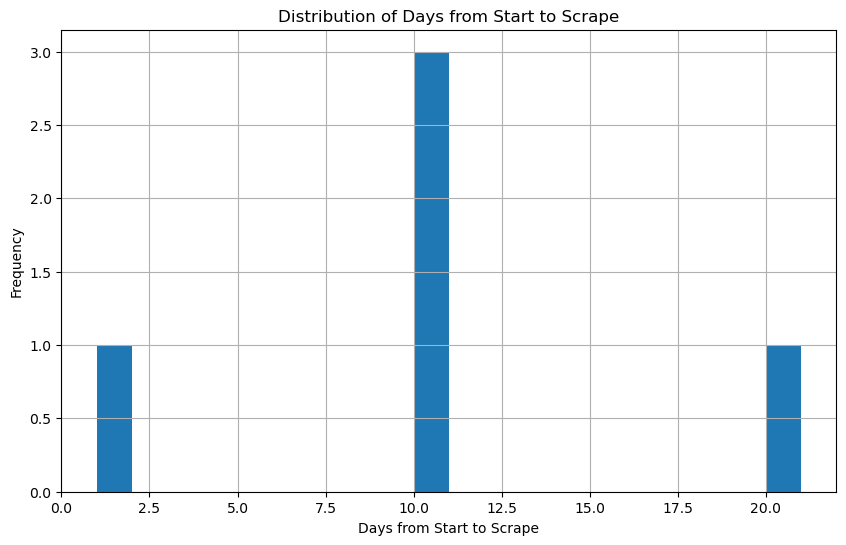

In [49]:
import matplotlib.pyplot as plt

# Assuming merged_df is your DataFrame and already contains the 'Days_from_start_to_scrape' column

# Create a plot of the 'Days_from_start_to_scrape'
plt.figure(figsize=(10, 6))
plt.hist(merged_df['Days_from_start_to_scrape'], bins=20)
plt.title('Distribution of Days from Start to Scrape')
plt.xlabel('Days from Start to Scrape')
plt.ylabel('Frequency')
plt.grid(True)

# Show the plot
plt.show()


In [63]:
import os

# Define the path to the test.txt file in the Scraping_files directory
test_file_path = os.path.join('Scraping_files', 'test.txt')

# Step 1: Read the IDs from test.txt
with open(test_file_path, 'r') as file:
    test_urls = file.readlines()

# Extract IDs from the URLs in test.txt
test_ids = [url.split('Id=')[-1].strip() for url in test_urls]

# Step 2: Get the unique IDs from the latest log data (log_df_latest)
log_ids_latest = log_df_latest['ID'].unique()

# Step 3: Find IDs that are in test.txt but not in the latest log data
missing_ids = set(test_ids) - set(log_ids_latest)

# Step 4: Display the missing IDs
print("Missing IDs:")
for missing_id in missing_ids:
    print(missing_id)


Missing IDs:
FT-02987


In [ ]:
pd.set_option('display.max_colwidth', None)  # Set None for no limit
print(df["Main Body"][0])